<a href="https://colab.research.google.com/github/sanvi-g07/ml-zoomcamp/blob/main/ml_zoomcamp_hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Get dataset

In [1]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

--2026-08-07 22:13:29--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv’

car_fuel_efficiency 100%[===================>] 853.70K  --.-KB/s    in 0.1s    

2026-08-07 22:13:30 (7.34 MB/s) - ‘car_fuel_efficiency.csv’ saved [874188/874188]



In [2]:
import pandas as pd

In [58]:
df = pd.read_csv("car_fuel_efficiency.csv")

In [59]:
df

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369
...,...,...,...,...,...,...,...,...,...,...,...
9699,140,5.0,164.0,2981.107371,17.3,2013,Europe,Diesel,Front-wheel drive,NaN,15.101802
9700,180,NaN,154.0,2439.525729,15.0,2004,USA,Gasoline,All-wheel drive,0.0,17.962326
9701,220,2.0,138.0,2583.471318,15.1,2008,USA,Diesel,All-wheel drive,-1.0,17.186587
9702,230,4.0,177.0,2905.527390,19.4,2011,USA,Diesel,Front-wheel drive,1.0,15.331551


#Prepare Dataset

In [60]:
df = df[["engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"]]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


#EDA

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

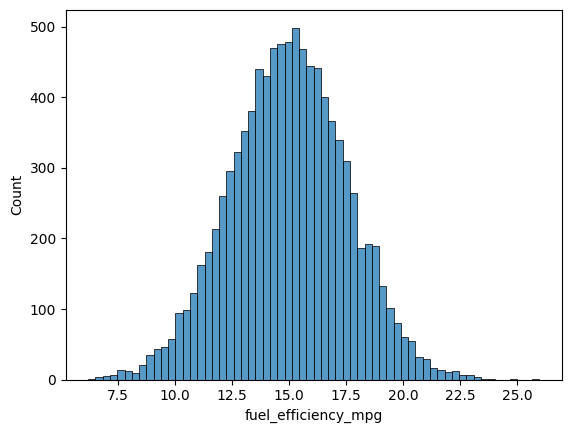

In [62]:
sns.histplot(df["fuel_efficiency_mpg"])

In [63]:
df.isnull().sum()

,0
engine_displacement,0
horsepower,708
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


In [64]:
df['horsepower'].describe()

,horsepower
count,8996.000000
mean,149.657292
std,29.879555
min,37.000000
25%,130.000000
50%,149.000000
75%,170.000000
max,271.000000


# Prepare and split dataset

In [65]:
import numpy as np

In [66]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [67]:
n, (n_val+n_test+n_train)

(9704, 9704)

In [68]:
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

In [69]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [70]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
483,220,144.0,2535.887591,2009,16.642943
7506,160,141.0,2741.170484,2019,16.298377
8795,230,155.0,2471.880237,2017,18.591822
1688,150,206.0,3748.164469,2015,11.818843
6217,300,111.0,2135.716359,2006,19.402209
...,...,...,...,...,...
1696,260,139.0,2606.972984,2009,16.964054
5685,280,132.0,4004.214323,2014,10.059094
6735,210,152.0,2500.175687,2020,17.593237
2052,250,154.0,2254.313245,2002,18.925748


In [71]:
y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

In [72]:
y_train

,fuel_efficiency_mpg
483,16.642943
7506,16.298377
8795,18.591822
1688,11.818843
6217,19.402209
...,...
1696,16.964054
5685,10.059094
6735,17.593237
2052,18.925748


In [73]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [74]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year
483,220,144.0,2535.887591,2009
7506,160,141.0,2741.170484,2019
8795,230,155.0,2471.880237,2017
1688,150,206.0,3748.164469,2015
6217,300,111.0,2135.716359,2006
...,...,...,...,...
1696,260,139.0,2606.972984,2009
5685,280,132.0,4004.214323,2014
6735,210,152.0,2500.175687,2020
2052,250,154.0,2254.313245,2002


Fill missing values from horsepower column with zeros

In [75]:
def prepare_X_zeros(df):
  df = df.copy()

  df = df.fillna(0)
  X = df.values
  return X

In [76]:
X_train_zeros = prepare_X_zeros(df_train)
X_train_zeros

array([[ 220.        ,  144.        , 2535.88759124, 2009.        ],
       [ 160.        ,  141.        , 2741.17048439, 2019.        ],
       [ 230.        ,  155.        , 2471.88023726, 2017.        ],
       ...,
       [ 210.        ,  152.        , 2500.17568746, 2020.        ],
       [ 250.        ,  154.        , 2254.31324473, 2002.        ],
       [ 210.        ,  152.        , 2435.20360628, 2004.        ]])

Fill missing values from horsepower column with mean of training dataset

In [77]:
def prepare_X_mean(df):
  df = df.copy()

  df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())
  X = df.values
  return X

In [78]:
X_train_mean = prepare_X_mean(df_train)
X_train_mean

array([[ 220.        ,  144.        , 2535.88759124, 2009.        ],
       [ 160.        ,  141.        , 2741.17048439, 2019.        ],
       [ 230.        ,  155.        , 2471.88023726, 2017.        ],
       ...,
       [ 210.        ,  152.        , 2500.17568746, 2020.        ],
       [ 250.        ,  154.        , 2254.31324473, 2002.        ],
       [ 210.        ,  152.        , 2435.20360628, 2004.        ]])

# Linear Regression model (w/o regularization)

## Train model

In [79]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [80]:
w0_zeros, w_zeros = train_linear_regression(X_train_zeros, y_train)
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)

In [81]:
y_pred_zeros = w0_zeros + X_train_zeros.dot(w_zeros)
y_pred_mean = w0_mean + X_train_mean.dot(w_mean)

## RMSE

In [82]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [83]:
rmse(y_train, y_pred_zeros)

np.float64(0.5202614265099076)

In [84]:
rmse(y_train, y_pred_mean)

np.float64(0.4624412137959964)

## Validate Model

In [85]:
X_val_zeros = prepare_X_zeros(df_val)
X_val_mean = prepare_X_mean(df_val)

In [86]:
y_pred_zeros = w0_zeros + X_val_zeros.dot(w_zeros)
y_pred_mean = w0_mean + X_val_mean.dot(w_mean)

In [87]:
round(rmse(y_val, y_pred_zeros), 2)

np.float64(0.52)

In [88]:
round(rmse(y_val, y_pred_mean), 2)

np.float64(0.46)

Filling the missing horsepower values with the mean results in a lower RMSE.

# Linear Regression (w/ regularization)

## Train model

In [89]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [90]:
w0_zeros, w_zeros = train_linear_regression_reg(X_train_zeros, y_train)

In [91]:
y_pred_zeros = w0_zeros + X_train_zeros.dot(w_zeros)

In [92]:
rmse(y_pred_zeros, y_train)

np.float64(0.5202635067133345)

## Validate model (test regularization paramter)

In [93]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
  w0_zeros, w_zeros = train_linear_regression_reg(X_train_zeros, y_train, r=r)
  y_pred_zeros = w0_zeros + X_val_zeros.dot(w_zeros)
  score = rmse(y_pred_zeros, y_val)
  print(r, round(score, 2))

0 0.52
0.01 0.52
0.1 0.52
1 0.52
5 0.52
10 0.52
100 0.52


#Test Different Random Seeds

In [97]:
seed_scores = np.array([])
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
  n = len(df)
  n_val = int(n * 0.2)
  n_test = int(n * 0.2)
  n_train = n - n_val - n_test

  idx = np.arange(n)
  np.random.seed(seed)
  np.random.shuffle(idx)

  df_train = df.iloc[idx[:n_train]]
  df_val = df.iloc[idx[n_train:n_train+n_val]]
  df_test = df.iloc[idx[n_train+n_val:]]

  y_train = df_train['fuel_efficiency_mpg']
  y_val = df_val['fuel_efficiency_mpg']
  y_test = df_test['fuel_efficiency_mpg']
  del df_train['fuel_efficiency_mpg']
  del df_val['fuel_efficiency_mpg']
  del df_test['fuel_efficiency_mpg']

  X_train = prepare_X_zeros(df_train)
  w0, w = train_linear_regression(X_train, y_train)

  X_val = prepare_X_zeros(df_val)
  y_pred_val = w0 + X_val.dot(w)

  score = rmse(y_val, y_pred_val)
  seed_scores = np.append(seed_scores, score)
  print(seed, score)

0 0.5206531296294218
1 0.521338891285577
2 0.5228069974803171
3 0.515951674119676
4 0.5109129460053851
5 0.52834064601107
6 0.5313910658146311
7 0.5090670387381733
8 0.5147399129511132
9 0.5131865908224594


In [98]:
seed_scores

array([0.52065313, 0.52133889, 0.522807  , 0.51595167, 0.51091295,
       0.52834065, 0.53139107, 0.50906704, 0.51473991, 0.51318659])

In [100]:
round(np.std(seed_scores), 3)

np.float64(0.007)

# Full train (train + validation) and test

In [102]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [106]:
# combine train and validation datasets
df_full_train = pd.concat([df_train, df_val])
y_full_train = np.concatenate([y_train, y_val])

In [107]:
df_full_train = df_full_train.reset_index(drop=True)
df_full_train

,engine_displacement,horsepower,vehicle_weight,model_year
0,240,136.0,4050.512290,2006
1,190,141.0,3195.866942,2017
2,200,184.0,3006.164370,2017
3,200,NaN,2947.143980,2022
4,250,132.0,3114.371978,2001
...,...,...,...,...
7759,200,167.0,3470.715658,2003
7760,180,144.0,3605.310144,2016
7761,180,154.0,3346.965671,2018
7762,210,152.0,2500.175687,2020


In [108]:
X_full_train = prepare_X_zeros(df_full_train)

In [109]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [112]:
X_test = prepare_X_zeros(df_test)
y_pred_test = w0 + X_test.dot(w)

In [113]:
rmse(y_test, y_pred_test)

np.float64(0.5156261299169602)